Experiment 3 from my thesis

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
 
# X_train
n_train = 50
X_train = np.random.normal(0, 1, n_train)
 
# Y = sinc(X) + noise
sigma_noise = 0.25
Y_train = np.sinc(X_train) + np.random.normal(0, sigma_noise, n_train)
 
# X_test
n_test = 25 #250
X_test = np.random.normal(0.5, 0.3, n_test)
 
Y_test = np.sinc(X_test) + np.random.normal(0, sigma_noise, n_test)
 
# w_i
def compute_weights(X_train, mu_train=0, sigma_train=1, mu_test=0.5, sigma_test=0.3):
    p_train = norm.pdf(X_train, mu_train, sigma_train)
    p_test  = norm.pdf(X_train, mu_test, sigma_test)
    return p_test / p_train
 
weights = compute_weights(X_train)

In [2]:
# use a linear model
def predict(X, theta):
    return theta[0] + theta[1] * X
 
# for single observation
def log_likelihood(y, x, theta, sigma=sigma_noise):
    y_pred = predict(x, theta)
    return norm.logpdf(y, y_pred, sigma)
 
# prior: Normal on both parameters
def log_prior(theta, mu=0, sigma=1):
    return np.sum(norm.logpdf(theta, mu, sigma))
 
 
# base score function for quasi-posterior: s_i(Y_i, theta) = w_i * log p(Y_i | theta)
def score_function(y, x, theta, weight):
    return weight * log_likelihood(y, x, theta)
 
# quasi-posterior with inverse temperature alpha: pi_alpha propto exp{alpha * sum_i s_i} * pi
def log_quasi_posterior(theta, Y, X, weights, alpha):
    log_qp = log_prior(theta)
    for i in range(len(Y)):
        log_qp += alpha * score_function(Y[i], X[i], theta, weights[i])
    return log_qp
 
# Sample from quasi-posterior (Metropolis-Hastings)
def sample_quasi_posterior(Y, X, weights, alpha, num_samples=7000, burn_in=100):
    theta = np.array([0.0, 0.0])  # initial value
    samples = []
    for i in range(num_samples + burn_in):
        # Propose new theta
        theta_new = theta + np.random.normal(loc=0, scale=0.35, size=2)
 
        # Acceptance ratio (renamed from log_alpha to avoid confusion with the alpha parameter)
        log_accept = (
            log_quasi_posterior(theta_new, Y, X, weights, alpha) -
            log_quasi_posterior(theta,     Y, X, weights, alpha)
        )
 
        # Accept/reject
        if np.log(np.random.rand()) < log_accept:
            theta = theta_new
 
        if i >= burn_in:
            samples.append(theta)
 
    return np.array(samples)
 
# Sample from quasi-posterior — fixed at alpha=1 (no alpha parameter in this PCIC)
posterior_samples = sample_quasi_posterior(Y_train, X_train, weights, alpha=1.0)
print(f"Sampled {len(posterior_samples)} posterior samples")
print(f"Posterior mean: {posterior_samples.mean(axis=0)}")
print(f"OLS: {np.polyfit(X_train, Y_train, deg=1)[::-1]}")


def compute_pcic(Y, X, weights, posterior_samples, lam, beta):
    """
    PCIC(lambda, beta) =
        -1/n  sum_i r(X_i)  log E_pos[ h(Y_i|X_i,theta) ]
      + beta/n  sum_i r(X_i)^{1+lambda}  V_pos[ log h(Y_i|X_i,theta) ]
    """
    n = len(Y)
    term1 = term2 = 0

    for i in range(n):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])

        # -r(X_i) * log E_pos[ h_i ]  (no beta in term1)
        log_expectation = logsumexp(log_liks) - np.log(len(posterior_samples))
        term1 -= weights[i] * log_expectation

        # r(X_i)^{1+lambda} * V_pos[ log h_i ]
        term2 += weights[i]**(1 + lam) * np.var(log_liks)

    # term2 scaled by beta before normalising
    pcic = (term1 + beta * term2) / n
    return pcic, term1, term2

Sampled 7000 posterior samples
Posterior mean: [ 0.97808077 -0.91681686]
OLS: [ 0.44446534 -0.04771458]


In [3]:
# -- Cell 3 --
# lam_default  = 0.0
# beta_default = 1.0
# pcic, term1, term2 = compute_pcic(Y_train, X_train, weights, posterior_samples, lam_default, beta_default)
# print(f"\nPCIC = {pcic:.4f}")
# print(f"  training loss: {term1:.4f}")
# print(f"  correction: {beta_default * term2:.4f}")

def compute_generalization_error(X_test, Y_test, posterior_samples):
    n_test = len(X_test)
    gen_error = 0
    for i in range(n_test):
        log_liks = np.array([
            log_likelihood(Y_test[i], X_test[i], theta) for theta in posterior_samples
        ])
        log_pred_density = logsumexp(log_liks) - np.log(len(posterior_samples))
        gen_error -= log_pred_density
    return gen_error / n_test

gen_error = compute_generalization_error(X_test, Y_test, posterior_samples)
print(f"True generalization error: {gen_error:.4f}")

True generalization error: 0.1236


In [4]:
# -- Cell 4: single sample replaces alpha sweep --
lambda_values = np.linspace(0.0, 2.0, 8)
beta_values   = np.linspace(0.25, 2.0, 8)

# posterior independent of lambda and beta — sample once
posterior_samples = sample_quasi_posterior(
    Y_train, X_train, weights, alpha=1.0, num_samples=2000, burn_in=200
)

In [5]:
# -- Cell 5 --

import matplotlib.pyplot as plt

def compute_waic(Y, X, posterior_samples, beta):
    total = 0
    for i in range(len(Y)):
        log_liks = np.array([log_likelihood(Y[i], X[i], theta) for theta in posterior_samples])
        log_expectation = logsumexp(log_liks) - np.log(len(posterior_samples))
        variance = np.var(log_liks)
        total += beta * variance - log_expectation   # beta scales variance directly (no lambda: no r weights)
    return total / len(Y)

# pcic_grid: 2D (lambda x beta); waic: 1D (beta only, no lambda); gen_error: scalar
pcic_grid     = np.zeros((len(lambda_values), len(beta_values)))
waic_per_beta = np.zeros(len(beta_values))

for i, lam in enumerate(lambda_values):
    for j, beta in enumerate(beta_values):
        pcic, _, _ = compute_pcic(
            Y_train, X_train, weights, posterior_samples, lam, beta
        )
        pcic_grid[i, j] = pcic

for j, beta in enumerate(beta_values):
    waic_per_beta[j] = compute_waic(
        Y_train, X_train, posterior_samples, beta
    )

# gen_error is a scalar — posterior is fixed
gen_error = compute_generalization_error(X_test, Y_test, posterior_samples)

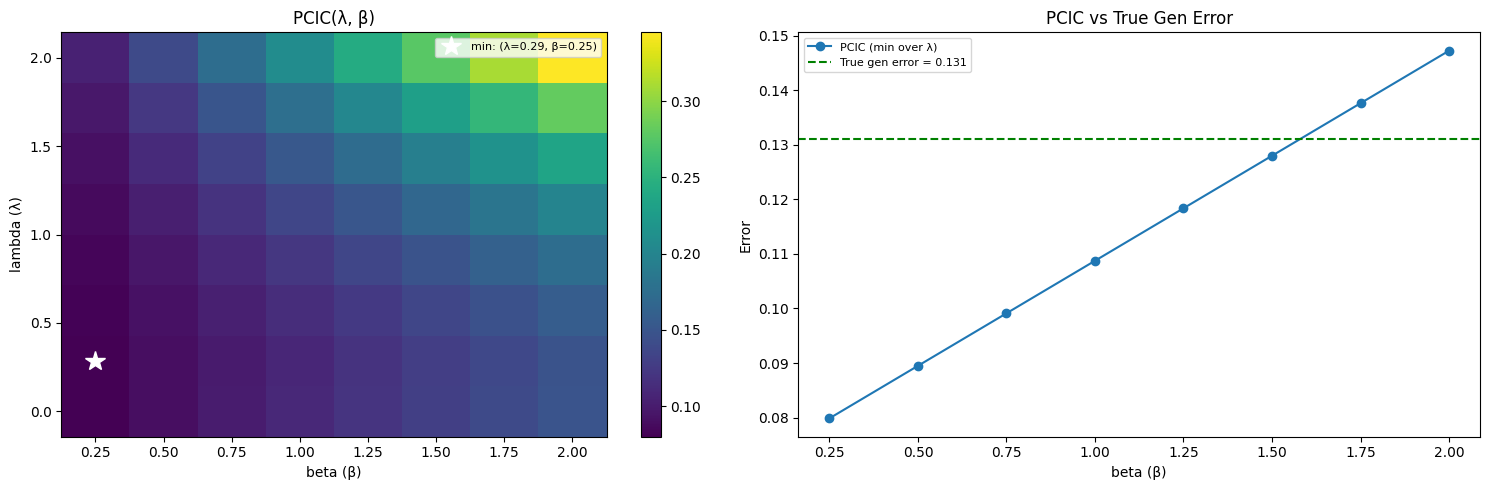

best (λ, β) according to PCIC:    (λ=0.29, β=0.25)
true generalization error:         0.1311


In [13]:
# -- Cell 6: plots --

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel 1: PCIC heatmap
# pcic_grid[i,j] at (lambda_values[i], beta_values[j]) — x=beta, y=lambda
B_grid, L_grid = np.meshgrid(beta_values, lambda_values)
im = axes[0].pcolormesh(B_grid, L_grid, pcic_grid, cmap='viridis', shading='nearest')
plt.colorbar(im, ax=axes[0])
min_idx = np.unravel_index(np.argmin(pcic_grid), pcic_grid.shape)
axes[0].plot(
    beta_values[min_idx[1]], lambda_values[min_idx[0]],
    'w*', markersize=15,
    label=f'min: (λ={lambda_values[min_idx[0]]:.2f}, β={beta_values[min_idx[1]]:.2f})'
)
axes[0].set_xlabel('beta (β)')
axes[0].set_ylabel('lambda (λ)')
axes[0].set_title('PCIC(λ, β)')
axes[0].legend(loc='upper right', fontsize=8)

# # Panel 2: WAIC vs beta (constant in lambda)
# axes[1].plot(beta_values, waic_per_beta, 'o-')
# min_waic_idx = np.argmin(waic_per_beta)
# axes[1].plot(beta_values[min_waic_idx], waic_per_beta[min_waic_idx], 'r*', markersize=12,
#              label=f'min β={beta_values[min_waic_idx]:.2f}')
# axes[1].axhline(gen_error, color='green', linestyle='--', label=f'True gen error = {gen_error:.3f}')
# axes[1].set_xlabel('beta (β)')
# axes[1].set_ylabel('WAIC')
# axes[1].set_title('WAIC(β)  [constant in λ]')
# axes[1].legend(loc='best', fontsize=8)

# Panel 3: best PCIC (min over lambda) vs WAIC vs true gen error as beta varies
pcic_min_over_lam = pcic_grid.min(axis=0)   # min over lambda for each beta
axes[1].plot(beta_values, pcic_min_over_lam, 'o-', label='PCIC (min over λ)')
# axes[2].plot(beta_values, waic_per_beta, 's-', label='WAIC')
axes[1].axhline(gen_error, color='green', linestyle='--', label=f'True gen error = {gen_error:.3f}')
axes[1].set_xlabel('beta (β)')
axes[1].set_ylabel('Error')
axes[1].set_title('PCIC vs True Gen Error')
axes[1].legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

print(f"best (λ, β) according to PCIC:    (λ={lambda_values[min_idx[0]]:.2f}, β={beta_values[min_idx[1]]:.2f})")
# print(f"best β according to WAIC:          {beta_values[min_waic_idx]:.2f}")
print(f"true generalization error:         {gen_error:.4f}")